In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("All India Consumer Price Index.csv")
print(df.head())

        Sector  Year  ... Miscellaneous  General index
0        Rural  2013  ...         104.0          105.1
1        Urban  2013  ...         103.7          104.0
2  Rural+Urban  2013  ...         103.9          104.6
3        Rural  2013  ...         104.4          105.8
4        Urban  2013  ...         104.3          104.7

[5 rows x 30 columns]


In [2]:
numeric_columns = ["Cereals and products","Meat and fish","Egg","Milk and products","Oils and fats","Fruits","Vegetables","Pulses and products","Sugar and Confectionery","Spices","Food and beverages","Clothing","Footwear","Housing","Fuel and light","Health","Transport and communication","Education","Miscellaneous","General index"]
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

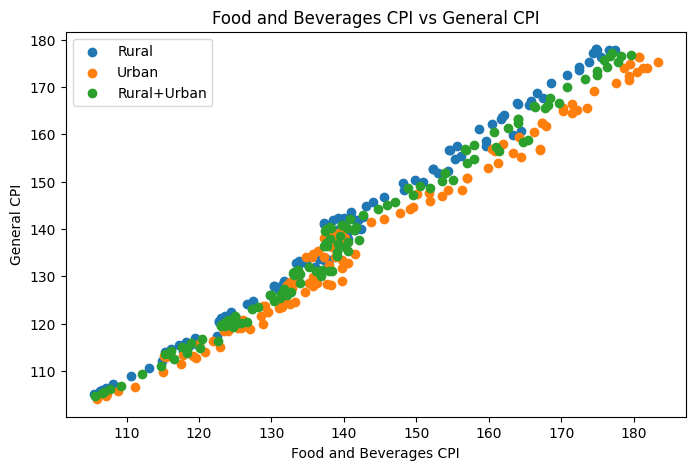

In [3]:
plt.figure(figsize=(8,5))
for sector in df["Sector"].dropna().unique():
    part = df[df["Sector"] == sector]
    plt.scatter(part["Food and beverages"], part["General index"], label=sector)
plt.title("Food and Beverages CPI vs General CPI")
plt.xlabel("Food and Beverages CPI")
plt.ylabel("General CPI")
plt.legend()
plt.show()

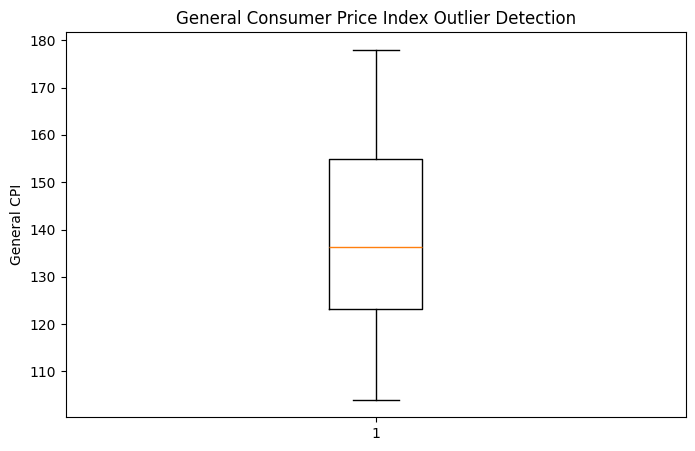

In [4]:
plt.figure(figsize=(8,5))
plt.boxplot(df["General index"].dropna())
plt.title("General Consumer Price Index Outlier Detection")
plt.ylabel("General CPI")
plt.show()

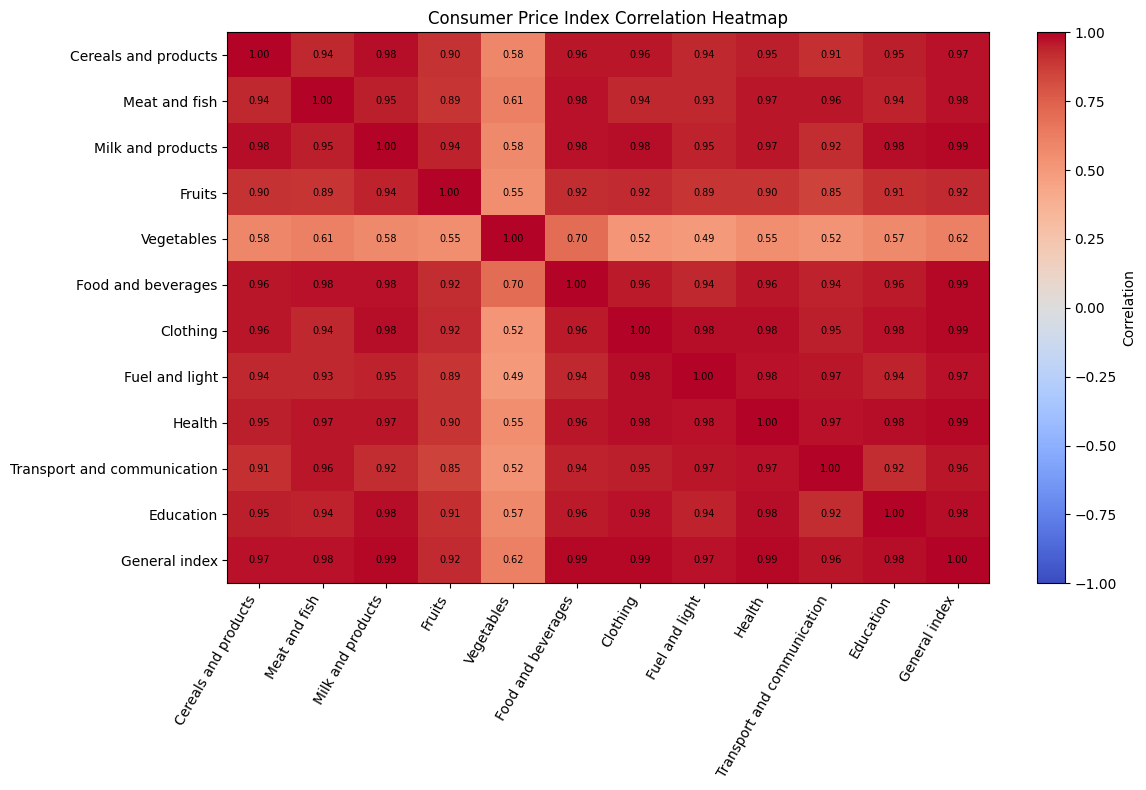

In [5]:
heatmap_columns = ["Cereals and products","Meat and fish","Milk and products","Fruits","Vegetables","Food and beverages","Clothing","Fuel and light","Health","Transport and communication","Education","General index"]
corr = df[heatmap_columns].corr()
plt.figure(figsize=(12,8))
plt.imshow(corr, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=60, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7)
plt.title("Consumer Price Index Correlation Heatmap")
plt.tight_layout()
plt.show()

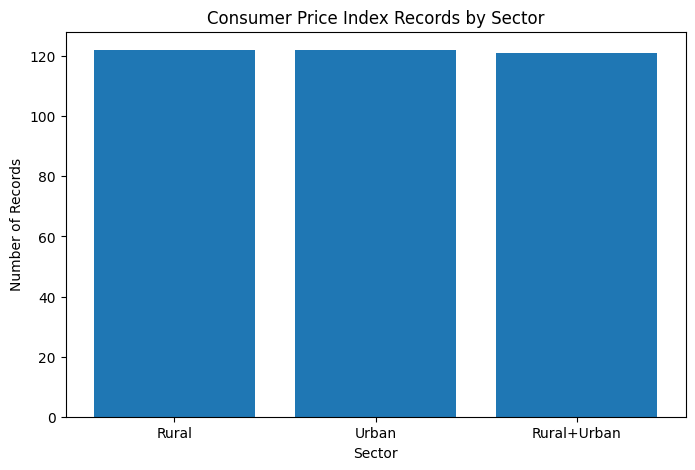

In [6]:
sector = df["Sector"].value_counts()
plt.figure(figsize=(8,5))
plt.bar(sector.index, sector.values)
plt.title("Consumer Price Index Records by Sector")
plt.xlabel("Sector")
plt.ylabel("Number of Records")
plt.show()

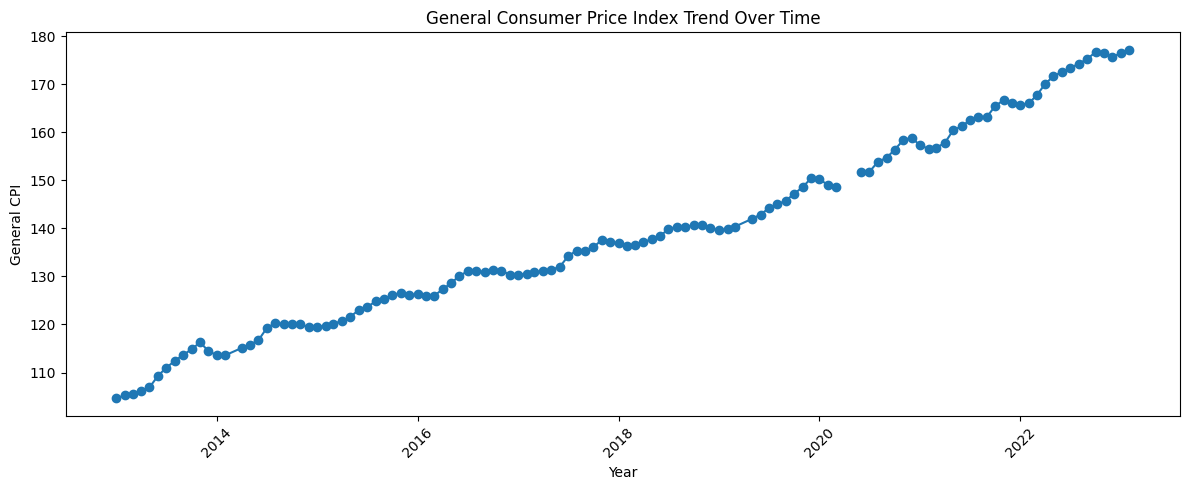

In [7]:
df["Date"] = pd.to_datetime(df["Month"] + " " + df["Year"].astype(str), format="%B %Y", errors="coerce")
overall = df[df["Sector"] == "Rural+Urban"].sort_values("Date")
plt.figure(figsize=(12,5))
plt.plot(overall["Date"], overall["General index"], marker="o")
plt.title("General Consumer Price Index Trend Over Time")
plt.xlabel("Year")
plt.ylabel("General CPI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

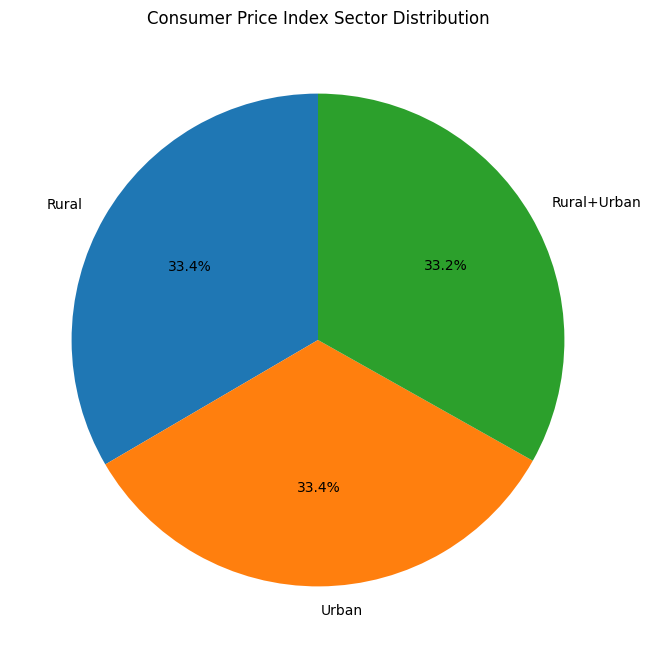

In [8]:
sector = df["Sector"].value_counts()
plt.figure(figsize=(8,8))
plt.pie(sector, labels=sector.index, autopct="%1.1f%%", startangle=90)
plt.title("Consumer Price Index Sector Distribution")
plt.show()

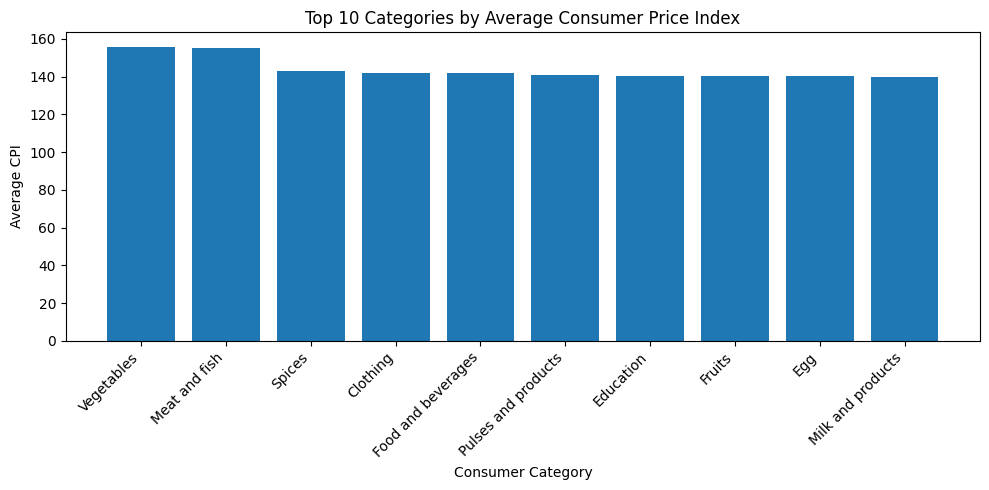

In [9]:
category_columns = ["Cereals and products","Meat and fish","Egg","Milk and products","Oils and fats","Fruits","Vegetables","Pulses and products","Sugar and Confectionery","Spices","Food and beverages","Clothing","Footwear","Housing","Fuel and light","Health","Transport and communication","Education","Miscellaneous"]
category_average = df[category_columns].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.bar(category_average.index, category_average.values)
plt.title("Top 10 Categories by Average Consumer Price Index")
plt.xlabel("Consumer Category")
plt.ylabel("Average CPI")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

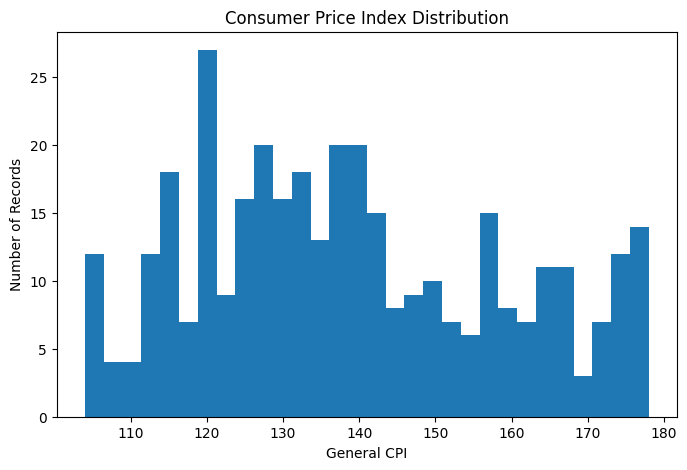

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df["General index"].dropna(), bins=30)
plt.title("Consumer Price Index Distribution")
plt.xlabel("General CPI")
plt.ylabel("Number of Records")
plt.show()

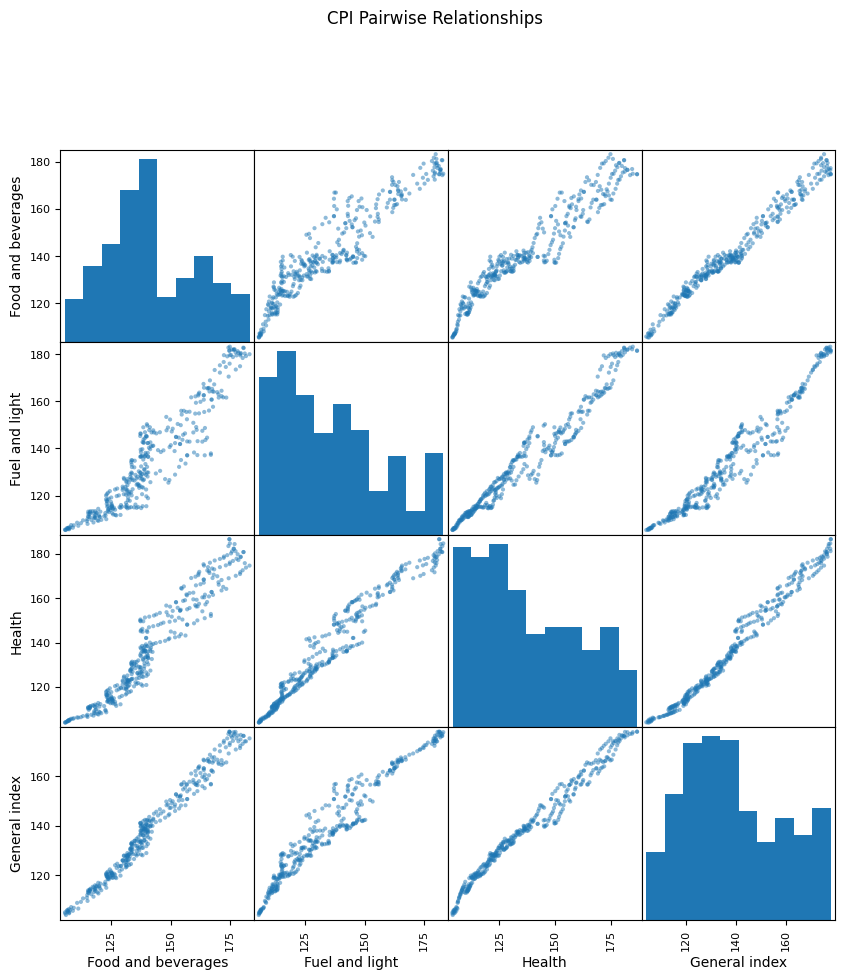

In [11]:
pair_columns = ["Food and beverages","Fuel and light","Health","General index"]
pair_df = df[pair_columns].dropna()
axes = pd.plotting.scatter_matrix(pair_df, figsize=(10,10), diagonal="hist")
plt.suptitle("CPI Pairwise Relationships", y=1.02)
plt.show()

In [12]:
print("======================================")
print("Experiment 5 Completed Successfully")
print("Scatter Plot Generated")
print("Box Plot Generated")
print("Correlation Heatmap Generated")
print("Count Plot Generated")
print("Line Plot Generated")
print("Pie Chart Generated")
print("Top 10 CPI Categories Visualized")
print("Histogram Generated")
print("Pair Plot Generated")
print("======================================")

Experiment 5 Completed Successfully
Scatter Plot Generated
Box Plot Generated
Correlation Heatmap Generated
Count Plot Generated
Line Plot Generated
Pie Chart Generated
Top 10 CPI Categories Visualized
Histogram Generated
Pair Plot Generated
